# QG ML Emulator - Ensemble PV Distribution Analysis

**Objective:** Analyze and compare Potential Vorticity (PV) distributions between:
- 2-layer QG Model (ground truth)
- ML Emulator (trained model)

**Dataset:**
- 1000 ensemble members
- Initialized identically through MLGETKF cycle
- Run for 3 hours (background ensemble)
- Grid: 64x64, 2 layers
- Variable: Potential Vorticity (PV)

## 1. Import Required Libraries

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from netCDF4 import Dataset
import warnings

# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load and Explore Data

In [83]:
# Load netCDF file
nc_path = "./Prediction_Target_ens1000.nc"
nc_file = Dataset(nc_path)

# Extract main variables
pv_qg = nc_file.variables['target_pv'][:]        # QG model: [ens, nz, ny, nx]
pv_ml = nc_file.variables['predicted_pv'][:]     # ML emulator: [ens, nz, ny, nx]

print("✓ Data loaded successfully")
print(f"\nData shapes:")
print(f"  PV QG model: {pv_qg.shape}")
print(f"  PV ML emulator: {pv_ml.shape}")
print(f"\nDimensions:")
print(f"  Ensemble members: {pv_qg.shape[0]}")
print(f"  Vertical layers: {pv_qg.shape[1]}")
print(f"  Spatial grid: {pv_qg.shape[2]}x{pv_qg.shape[3]}")

✓ Data loaded successfully

Data shapes:
  PV QG model: (1000, 2, 64, 64)
  PV ML emulator: (1000, 2, 64, 64)

Dimensions:
  Ensemble members: 1000
  Vertical layers: 2
  Spatial grid: 64x64


## 3. Visualize PV Fields

Display the spatial structure of Potential Vorticity from both QG model and ML emulator at different ensemble members and layers.

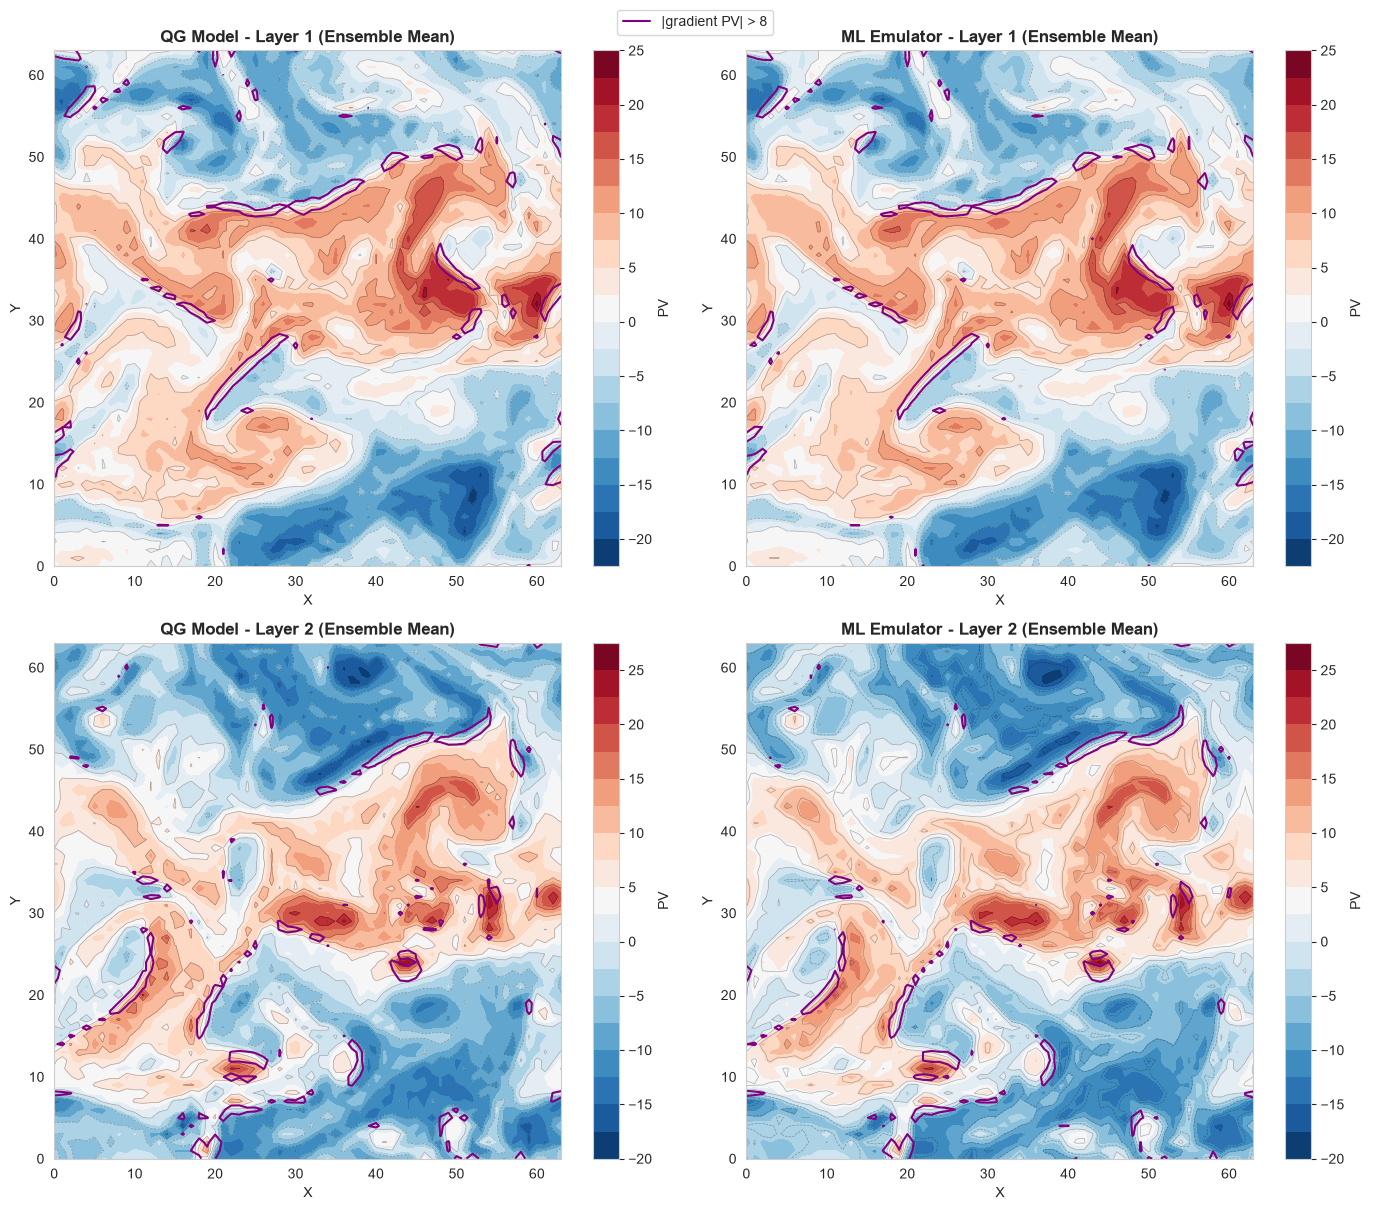

✓ Saved: pv_fields_ensemble_mean.png


In [84]:
# Plot ensemble mean PV fields for both layers
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Compute ensemble means
pv_qg_mean_l0 = np.mean(pv_qg[:, 0, :, :], axis=0)
pv_ml_mean_l0 = np.mean(pv_ml[:, 0, :, :], axis=0)
pv_qg_mean_l1 = np.mean(pv_qg[:, 1, :, :], axis=0)
pv_ml_mean_l1 = np.mean(pv_ml[:, 1, :, :], axis=0)

# Compute horizontal PV-gradient magnitudes for the contour overlay
def pv_gradient_magnitude(field):
    grad_y, grad_x = np.gradient(np.asarray(field))
    return np.hypot(grad_x, grad_y)

pv_gradient_threshold = 7.5
pv_qg_gradient_l0 = pv_gradient_magnitude(pv_qg_mean_l0)
pv_ml_gradient_l0 = pv_gradient_magnitude(pv_ml_mean_l0)
pv_qg_gradient_l1 = pv_gradient_magnitude(pv_qg_mean_l1)
pv_ml_gradient_l1 = pv_gradient_magnitude(pv_ml_mean_l1)

# Layer 1 - QG Model
im1 = axes[0, 0].contourf(pv_qg_mean_l0, levels=20, cmap='RdBu_r')
axes[0, 0].contour(pv_qg_mean_l0, levels=10, colors='black', linewidths=0.5, alpha=0.3)
axes[0, 0].contour(pv_qg_gradient_l0, levels=[pv_gradient_threshold], colors='purple', linewidths=1.5)
axes[0, 0].set_title('QG Model - Layer 1 (Ensemble Mean)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')
cbar1 = plt.colorbar(im1, ax=axes[0, 0])
cbar1.set_label('PV')

# Layer 1 - ML Emulator
im2 = axes[0, 1].contourf(pv_ml_mean_l0, levels=20, cmap='RdBu_r')
axes[0, 1].contour(pv_ml_mean_l0, levels=10, colors='black', linewidths=0.5, alpha=0.3)
axes[0, 1].contour(pv_ml_gradient_l0, levels=[pv_gradient_threshold], colors='purple', linewidths=1.5)
axes[0, 1].set_title('ML Emulator - Layer 1 (Ensemble Mean)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Y')
cbar2 = plt.colorbar(im2, ax=axes[0, 1])
cbar2.set_label('PV')

# Layer 2 - QG Model
im3 = axes[1, 0].contourf(pv_qg_mean_l1, levels=20, cmap='RdBu_r')
axes[1, 0].contour(pv_qg_mean_l1, levels=10, colors='black', linewidths=0.5, alpha=0.3)
axes[1, 0].contour(pv_qg_gradient_l1, levels=[pv_gradient_threshold], colors='purple', linewidths=1.5)
axes[1, 0].set_title('QG Model - Layer 2 (Ensemble Mean)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
cbar3 = plt.colorbar(im3, ax=axes[1, 0])
cbar3.set_label('PV')

# Layer 2 - ML Emulator
im4 = axes[1, 1].contourf(pv_ml_mean_l1, levels=20, cmap='RdBu_r')
axes[1, 1].contour(pv_ml_mean_l1, levels=10, colors='black', linewidths=0.5, alpha=0.3)
axes[1, 1].contour(pv_ml_gradient_l1, levels=[pv_gradient_threshold], colors='purple', linewidths=1.5)
axes[1, 1].set_title('ML Emulator - Layer 2 (Ensemble Mean)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
cbar4 = plt.colorbar(im4, ax=axes[1, 1])
cbar4.set_label('PV')

fig.legend(
    handles=[plt.Line2D([0], [0], color='purple', linewidth=1.5, label='|gradient PV| > 8')],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),
)
plt.tight_layout()
plt.savefig('pv_fields_ensemble_mean.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: pv_fields_ensemble_mean.png")

### 3.1. Spatial Gradient of the PV Fields

The following maps show the magnitude of the horizontal PV gradient,
$|\nabla PV| = \sqrt{(\partial PV/\partial x)^2 + (\partial PV/\partial y)^2}$,
computed from the ensemble-mean fields. White contours delimit the 10% largest gradients in each panel, and the cyan marker identifies the maximum.

> **Note:** the NetCDF file contains PV but not potential temperature. Therefore, these maps identify strong **PV gradients**, which may indicate frontal regions, but they are not a direct calculation of $|\nabla\theta|$.

QG Model - Layer 1: maximum |gradient PV| at (y=11, x=63) = 15.490611
ML Emulator - Layer 1: maximum |gradient PV| at (y=11, x=63) = 13.886293
QG Model - Layer 2: maximum |gradient PV| at (y=1, x=20) = 14.224319
ML Emulator - Layer 2: maximum |gradient PV| at (y=1, x=20) = 14.390457


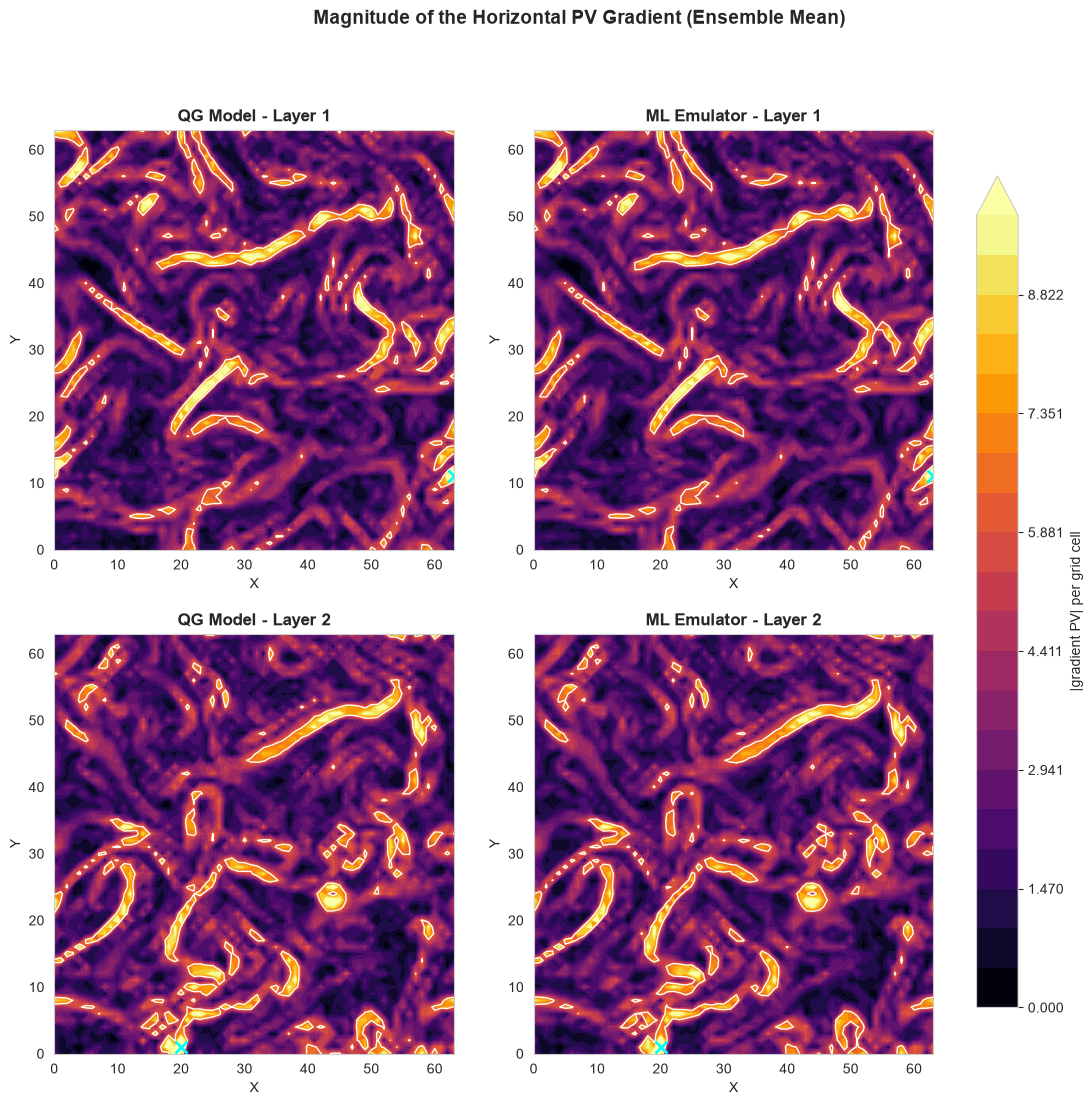

✓ Saved: pv_gradient_magnitude_ensemble_mean.png


In [85]:
# Compute the horizontal gradient magnitude of each ensemble-mean PV field
def gradient_magnitude(field):
    grad_y, grad_x = np.gradient(np.asarray(field))
    return np.hypot(grad_x, grad_y)

gradient_fields = [
    gradient_magnitude(pv_qg_mean_l0),
    gradient_magnitude(pv_ml_mean_l0),
    gradient_magnitude(pv_qg_mean_l1),
    gradient_magnitude(pv_ml_mean_l1),
]

gradient_titles = [
    'QG Model - Layer 1',
    'ML Emulator - Layer 1',
    'QG Model - Layer 2',
    'ML Emulator - Layer 2',
]

# Use a common color scale so that all panels can be compared directly
vmax = np.percentile(np.concatenate([field.ravel() for field in gradient_fields]), 99)
levels = np.linspace(0, vmax, 21)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, gradient, title in zip(axes.flat, gradient_fields, gradient_titles):
    image = ax.contourf(gradient, levels=levels, cmap='inferno', extend='max')

    # Delimit the 10% strongest gradients in this field
    strong_gradient_threshold = np.percentile(gradient, 90)
    ax.contour(
        gradient,
        levels=[strong_gradient_threshold],
        colors='white',
        linewidths=1.0,
    )

    # Mark the grid point containing the maximum gradient
    max_y, max_x = np.unravel_index(np.argmax(gradient), gradient.shape)
    ax.plot(max_x, max_y, marker='x', color='cyan', markersize=9, markeredgewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    print(f'{title}: maximum |gradient PV| at (y={max_y}, x={max_x}) = {gradient[max_y, max_x]:.6f}')

fig.suptitle('Magnitude of the Horizontal PV Gradient (Ensemble Mean)', fontsize=14, fontweight='bold')
colorbar = fig.colorbar(image, ax=axes, shrink=0.9, pad=0.04)
colorbar.set_label('|gradient PV| per grid cell')
plt.savefig('pv_gradient_magnitude_ensemble_mean.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Saved: pv_gradient_magnitude_ensemble_mean.png')

## 4. Basic Statistics

In [86]:
# Basic statistics
print("=" * 60)
print("STATISTICS - QG MODEL (GROUND TRUTH)")
print("=" * 60)
print(f"Mean:       {np.mean(pv_qg):12.8f}")
print(f"Std Dev:    {np.std(pv_qg):12.8f}")
print(f"Minimum:    {np.min(pv_qg):12.8f}")
print(f"Maximum:    {np.max(pv_qg):12.8f}")
print(f"Median:     {np.median(pv_qg):12.8f}")

print("\n" + "=" * 60)
print("STATISTICS - ML EMULATOR")
print("=" * 60)
print(f"Mean:       {np.mean(pv_ml):12.8f}")
print(f"Std Dev:    {np.std(pv_ml):12.8f}")
print(f"Minimum:    {np.min(pv_ml):12.8f}")
print(f"Maximum:    {np.max(pv_ml):12.8f}")
print(f"Median:     {np.median(pv_ml):12.8f}")

print("\n" + "=" * 60)
print("DIFFERENCES (ML - QG)")
print("=" * 60)
diff = pv_ml - pv_qg
print(f"Mean absolute error:  {np.mean(np.abs(diff)):12.8f}")
print(f"RMSE:        {np.sqrt(np.mean(diff**2)):12.8f}")
print(f"Max error:   {np.max(np.abs(diff)):12.8f}")

STATISTICS - QG MODEL (GROUND TRUTH)
Mean:        -0.01841136
Std Dev:      8.28531361
Minimum:    -26.76558304
Maximum:     35.34888458
Median:      -0.01241100

STATISTICS - ML EMULATOR
Mean:        -0.01020110
Std Dev:      8.23667526
Minimum:    -26.40765953
Maximum:     30.44390106
Median:      -0.01320564

DIFFERENCES (ML - QG)
Mean absolute error:    0.61956177
RMSE:          0.80783303
Max error:     8.05685425


## 5. Normality Analysis at Various Grid Points

We will analyze whether the ensemble distributions are Gaussian or not at different grid points:
- **Central points**: Typically smoother
- **Points with gradients**: Expected to be more non-Gaussian
- **Nearby points**: We combine several points to increase ensemble data

In [87]:
def analyze_normality(data, layer, y, x, window_size=0):
    """
    Analyze normality at a specific grid point
    
    Parameters:
    -----------
    data: array [ens, nz, ny, nx]
    layer: vertical layer index
    y, x: grid point coordinates
    window_size: if > 0, average over a window around the point
    
    Returns:
    --------
    dict with analysis results
    """
    
    if window_size > 0:
        # Extract window around the point
        y_start = max(0, y - window_size)
        y_end = min(data.shape[2], y + window_size + 1)
        x_start = max(0, x - window_size)
        x_end = min(data.shape[3], x + window_size + 1)
        
        # Average in space, maintain ensemble
        ensemble_vals = data[:, layer, y_start:y_end, x_start:x_end].mean(axis=(1, 2))
    else:
        # Only the specific point
        ensemble_vals = data[:, layer, y, x]
    
    # Normality tests
    stat_sw, p_sw = stats.shapiro(ensemble_vals)  # Shapiro-Wilk
    stat_ks, p_ks = stats.kstest((ensemble_vals - np.mean(ensemble_vals)) / np.std(ensemble_vals), 
                                  'norm')  # Kolmogorov-Smirnov
    
    # Skewness and Kurtosis
    skew = stats.skew(ensemble_vals)
    kurt = stats.kurtosis(ensemble_vals)
    
    return {
        'mean': np.mean(ensemble_vals),
        'std': np.std(ensemble_vals),
        'skew': skew,
        'kurtosis': kurt,
        'shapiro_stat': stat_sw,
        'shapiro_p': p_sw,
        'ks_stat': stat_ks,
        'ks_p': p_ks,
        'values': ensemble_vals
    }

print("✓ Function analyze_normality defined")

✓ Function analyze_normality defined


In [88]:
# Select interesting points for analysis
# Layer 1 (top layer)
manual_points = {
    'Center (32,32)': (32, 32),
    'NE Corner (48,48)': (48, 48),
    'SW Corner (16,16)': (16, 16),
    'North Edge (16,32)': (16, 32),
    'South Edge (48,32)': (48, 32),
    'West Edge (11,63)': (11, 63),
    'East Edge (32,48)': (32, 48),
}

# Select spatially separated points from the QG ensemble-mean PV gradient.
# A two-grid-cell border is excluded to avoid one-sided-gradient edge effects.
def select_spaced_gradient_points(gradient, candidate_mask, number=4, min_distance=8,
                                  largest=True, excluded_points=()):
    candidate_indices = np.argwhere(candidate_mask)
    candidate_values = gradient[candidate_mask]
    order = np.argsort(candidate_values)
    if largest:
        order = order[::-1]

    selected = []
    blocked = list(excluded_points)
    for index in order:
        y, x = map(int, candidate_indices[index])
        if all(np.hypot(y - other_y, x - other_x) >= min_distance
               for other_y, other_x in blocked + selected):
            selected.append((y, x))
            if len(selected) == number:
                break
    return selected

interior_mask = np.zeros_like(pv_qg_gradient_l0, dtype=bool)
interior_mask[2:-2, 2:-2] = True
high_gradient_threshold = 7.5
low_gradient_threshold = np.percentile(pv_qg_gradient_l0[interior_mask], 10)

high_gradient_points = select_spaced_gradient_points(
    pv_qg_gradient_l0,
    interior_mask & (pv_qg_gradient_l0 > high_gradient_threshold),
    excluded_points=manual_points.values(),
)
low_gradient_points = select_spaced_gradient_points(
    pv_qg_gradient_l0,
    interior_mask & (pv_qg_gradient_l0 <= low_gradient_threshold),
    largest=False,
    excluded_points=list(manual_points.values()) + high_gradient_points,
)

gradient_points = {
    **{
        f'High gradient {i} (|grad PV|={pv_qg_gradient_l0[y, x]:.2f})': (y, x)
        for i, (y, x) in enumerate(high_gradient_points, start=1)
    },
    **{
        f'Low gradient {i} (|grad PV|={pv_qg_gradient_l0[y, x]:.2f})': (y, x)
        for i, (y, x) in enumerate(low_gradient_points, start=1)
    },
}
points = {**manual_points, **gradient_points}

print(f'High-gradient criterion: |grad PV| > {high_gradient_threshold:.1f}')
print(f'Low-gradient criterion: bottom 10% (|grad PV| <= {low_gradient_threshold:.3f})')
print(f'Selected high-gradient points: {high_gradient_points}')
print(f'Selected low-gradient points:  {low_gradient_points}\n')

# Analyze QG Model
print("=" * 80)
print("NORMALITY ANALYSIS - QG MODEL (Layer 1)")
print("=" * 80)

results_qg = {}
for name, (y, x) in points.items():
    res = analyze_normality(pv_qg, layer=0, y=y, x=x, window_size=0)
    results_qg[name] = res
    
    is_gaussian = "✓ Gaussian" if res['shapiro_p'] > 0.05 else "✗ Non-Gaussian"
    print(f"\n{name}: ({y},{x})")
    print(f"  Shapiro-Wilk p-value: {res['shapiro_p']:.6f} {is_gaussian}")
    print(f"  Skewness: {res['skew']:8.4f}  |  Kurtosis: {res['kurtosis']:8.4f}")

# Analyze ML Emulator
print("\n" + "=" * 80)
print("NORMALITY ANALYSIS - ML EMULATOR (Layer 1)")
print("=" * 80)

results_ml = {}
for name, (y, x) in points.items():
    res = analyze_normality(pv_ml, layer=0, y=y, x=x, window_size=0)
    results_ml[name] = res
    
    is_gaussian = "✓ Gaussian" if res['shapiro_p'] > 0.05 else "✗ Non-Gaussian"
    print(f"\n{name}: ({y},{x})")
    print(f"  Shapiro-Wilk p-value: {res['shapiro_p']:.6f} {is_gaussian}")
    print(f"  Skewness: {res['skew']:8.4f}  |  Kurtosis: {res['kurtosis']:8.4f}")

# Compare normality between high- and low-gradient locations
def summarize_gradient_group(results, prefix):
    group = [result for name, result in results.items() if name.startswith(prefix)]
    return {
        'count': len(group),
        'non_gaussian': sum(result['shapiro_p'] <= 0.05 for result in group),
        'median_p': np.median([result['shapiro_p'] for result in group]),
        'mean_abs_skew': np.mean([abs(result['skew']) for result in group]),
        'mean_abs_kurtosis': np.mean([abs(result['kurtosis']) for result in group]),
    }

print("\n" + "=" * 80)
print("HIGH- VS LOW-GRADIENT NORMALITY COMPARISON")
print("=" * 80)
for model_name, model_results in [('QG', results_qg), ('ML', results_ml)]:
    for group_name, prefix in [('High gradient', 'High gradient'),
                               ('Low gradient', 'Low gradient')]:
        summary = summarize_gradient_group(model_results, prefix)
        print(
            f"{model_name:>2} - {group_name:<13}: "
            f"non-Gaussian {summary['non_gaussian']}/{summary['count']}, "
            f"median Shapiro p={summary['median_p']:.3e}, "
            f"mean |skew|={summary['mean_abs_skew']:.3f}, "
            f"mean |kurtosis|={summary['mean_abs_kurtosis']:.3f}"
        )

High-gradient criterion: |grad PV| > 7.5
Low-gradient criterion: bottom 10% (|grad PV| <= 0.791)
Selected high-gradient points: [(26, 26), (52, 15), (57, 4), (44, 22)]
Selected low-gradient points:  [(24, 42), (54, 60), (7, 38), (17, 54)]

NORMALITY ANALYSIS - QG MODEL (Layer 1)

Center (32,32): (32,32)
  Shapiro-Wilk p-value: 0.000001 ✗ Non-Gaussian
  Skewness:  -0.4244  |  Kurtosis:   0.5977

NE Corner (48,48): (48,48)
  Shapiro-Wilk p-value: 0.202821 ✓ Gaussian
  Skewness:  -0.1542  |  Kurtosis:  -0.0166

SW Corner (16,16): (16,16)
  Shapiro-Wilk p-value: 0.201648 ✓ Gaussian
  Skewness:   0.1016  |  Kurtosis:   0.2356

North Edge (16,32): (16,32)
  Shapiro-Wilk p-value: 0.394196 ✓ Gaussian
  Skewness:  -0.0705  |  Kurtosis:   0.1500

South Edge (48,32): (48,32)
  Shapiro-Wilk p-value: 0.086587 ✓ Gaussian
  Skewness:  -0.1024  |  Kurtosis:  -0.1310

West Edge (11,63): (11,63)
  Shapiro-Wilk p-value: 0.000000 ✗ Non-Gaussian
  Skewness:  -0.4156  |  Kurtosis:   0.0276

East Edge (32,48

### 5.1. QG Distributions at High- and Low-Gradient Points

For every automatically selected point, an individual figure compares the empirical QG distribution with a Gaussian distribution using:

- **(a)** a normalized histogram with the fitted Gaussian density;
- **(b)** a Q–Q plot against the theoretical normal distribution.

The reported kurtosis is the **Fisher excess kurtosis** used by `scipy.stats.kurtosis`; a Gaussian distribution has kurtosis 0 under this convention (equivalent to Pearson kurtosis 3).

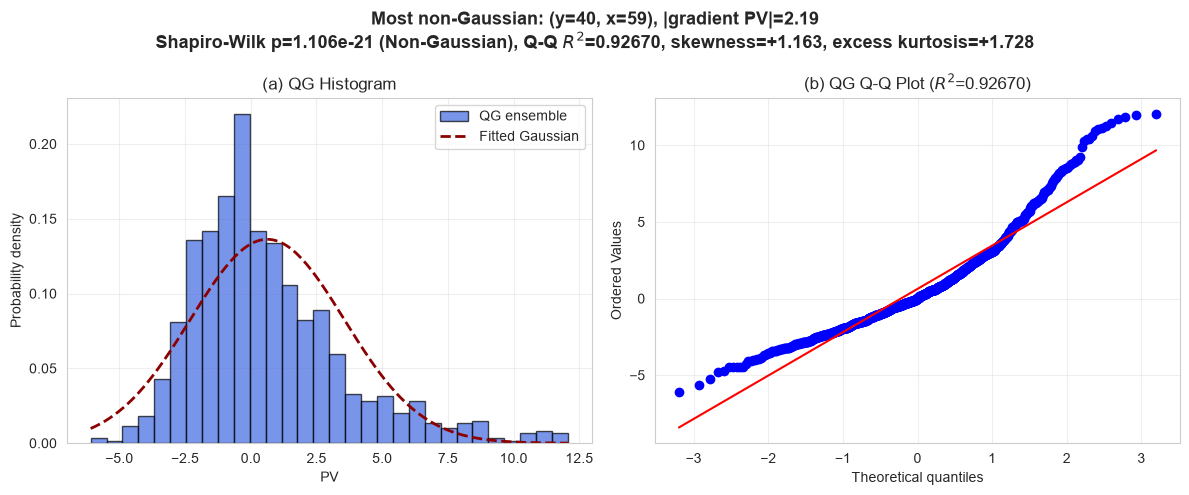

✓ Saved: qg_most_non-gaussian_y40_x59.png


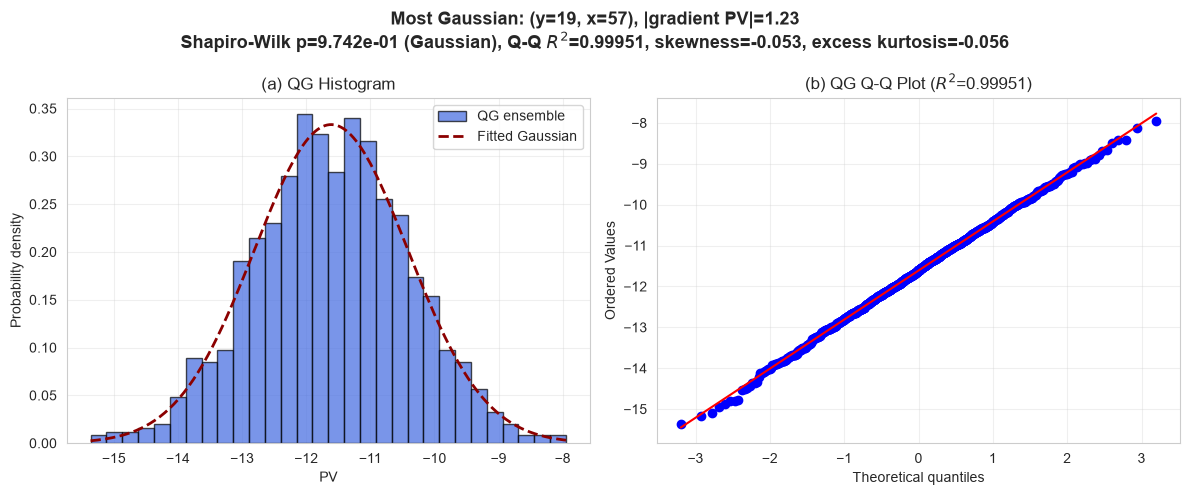

✓ Saved: qg_most_gaussian_y19_x57.png


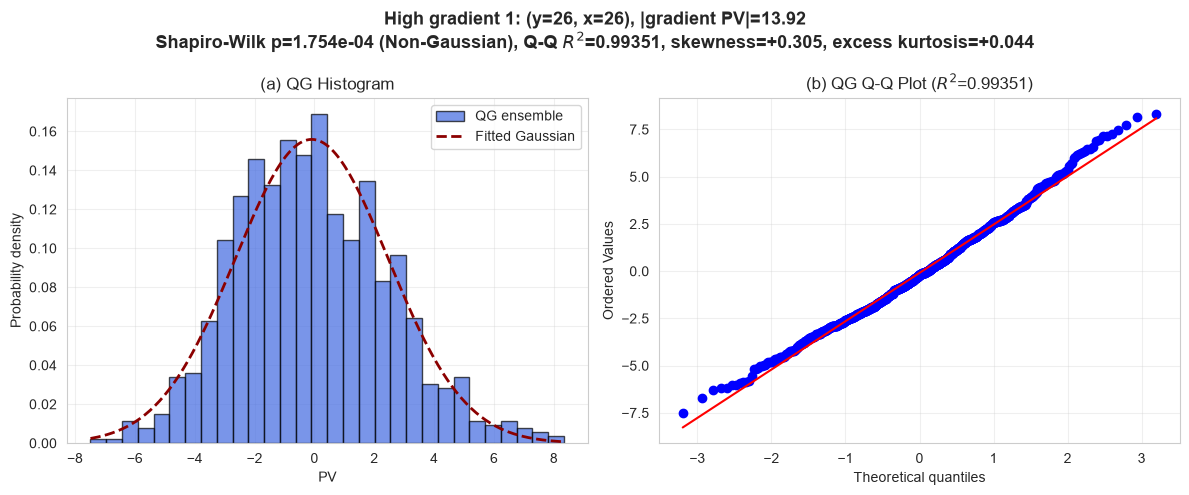

✓ Saved: qg_high_gradient_1_y26_x26.png


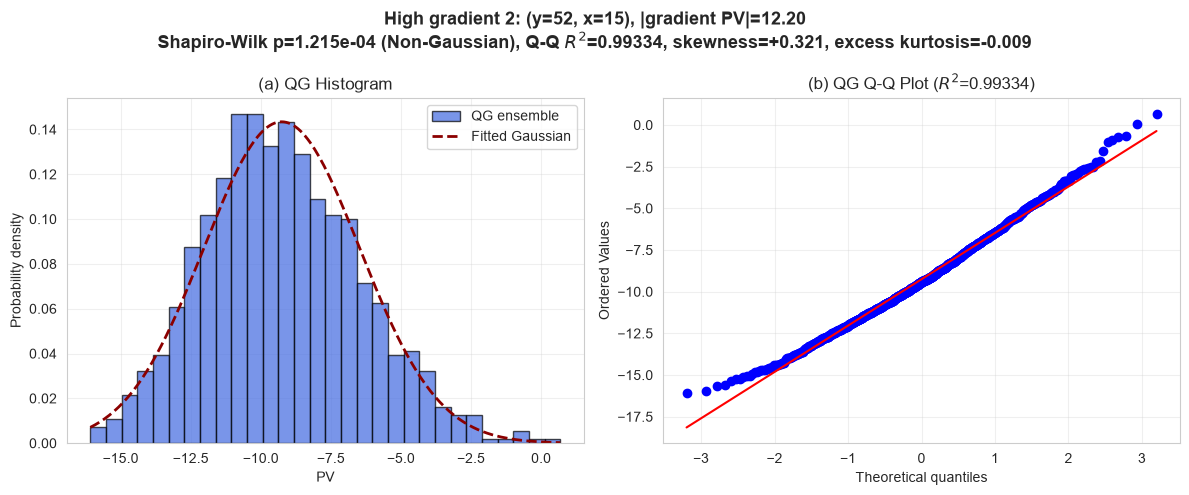

✓ Saved: qg_high_gradient_2_y52_x15.png


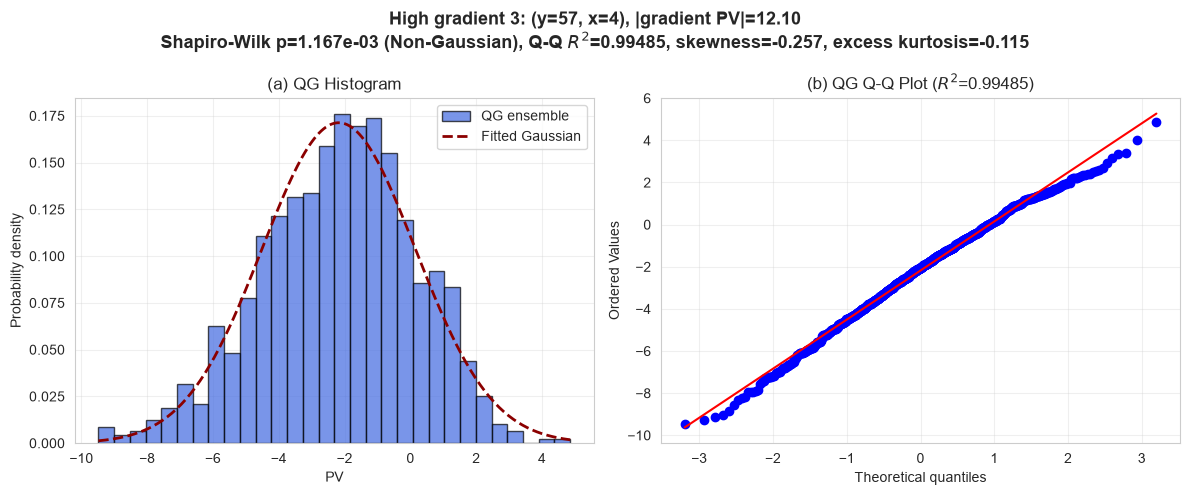

✓ Saved: qg_high_gradient_3_y57_x4.png


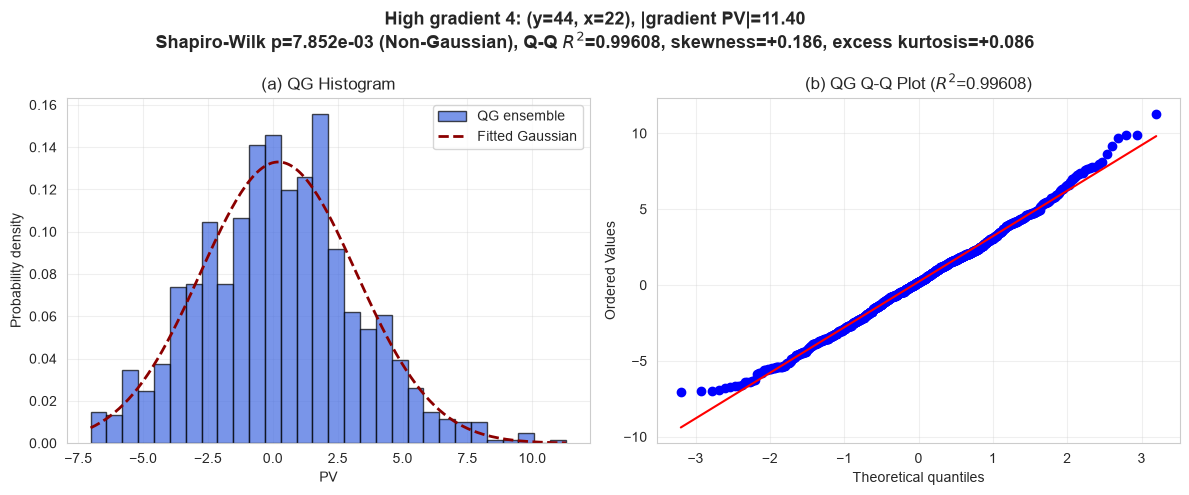

✓ Saved: qg_high_gradient_4_y44_x22.png


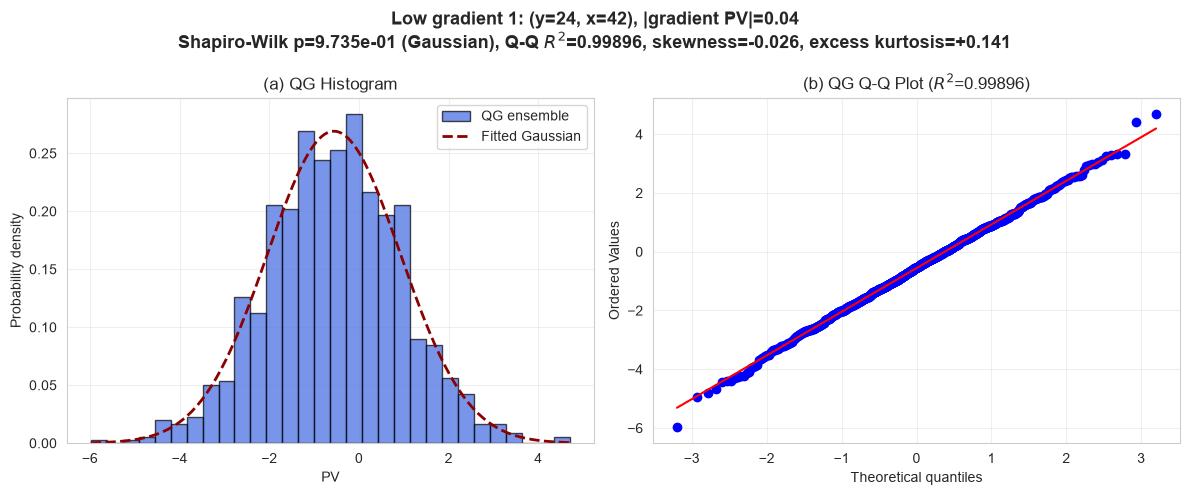

✓ Saved: qg_low_gradient_1_y24_x42.png


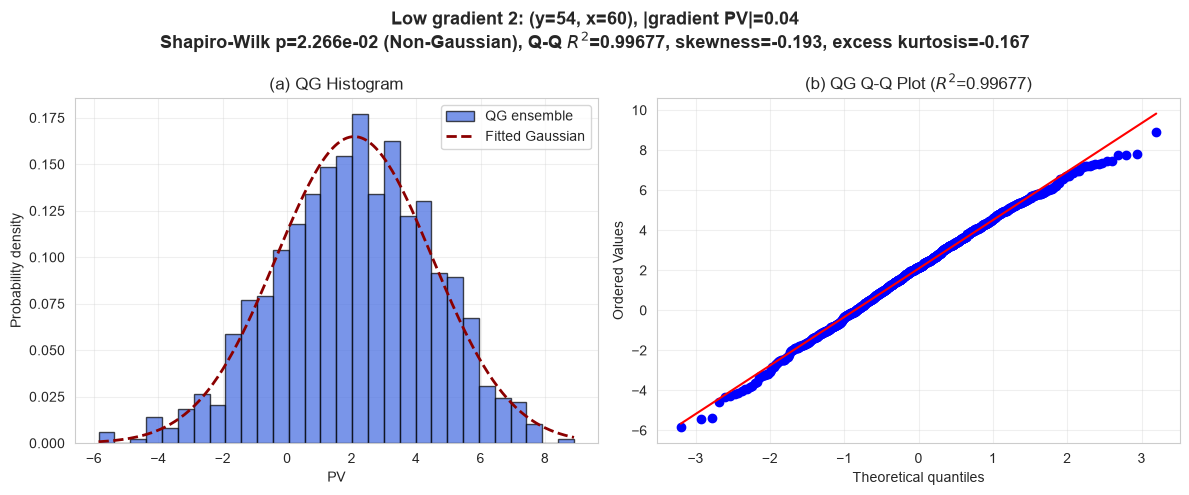

✓ Saved: qg_low_gradient_2_y54_x60.png


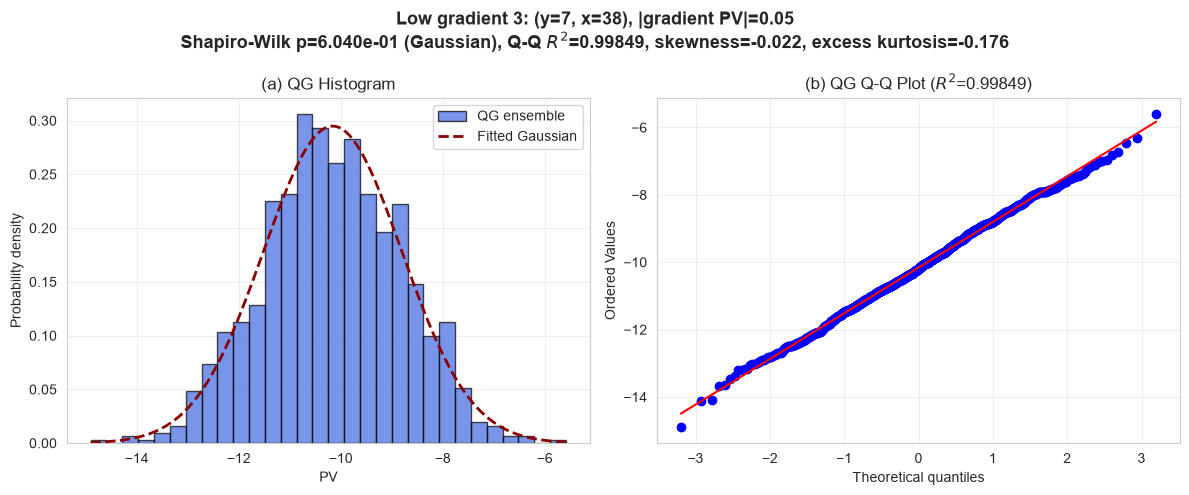

✓ Saved: qg_low_gradient_3_y7_x38.png


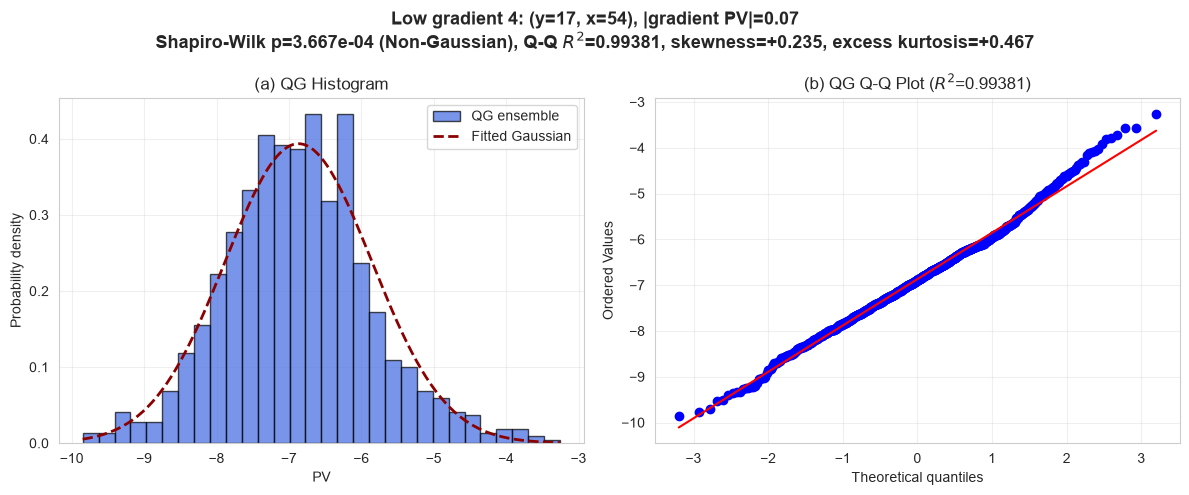

✓ Saved: qg_low_gradient_4_y17_x54.png


In [89]:
# Create one QG histogram and Q-Q figure for every selected gradient point
qg_gradient_comparison_points = {
    'Most non-Gaussian': (40, 59),
    'Most Gaussian': (19, 57),
    **{
        f'High gradient {i}': (y, x)
        for i, (y, x) in enumerate(high_gradient_points, start=1)
    },
    **{
        f'Low gradient {i}': (y, x)
        for i, (y, x) in enumerate(low_gradient_points, start=1)
    },
}

for point_name, (y, x) in qg_gradient_comparison_points.items():
    qg_values = np.asarray(pv_qg[:, 0, y, x])
    gradient_value = pv_qg_gradient_l0[y, x]
    shapiro_p = stats.shapiro(qg_values).pvalue
    qg_skewness = stats.skew(qg_values)
    qg_kurtosis = stats.kurtosis(qg_values, fisher=True)
    normality_label = 'Gaussian' if shapiro_p > 0.05 else 'Non-Gaussian'

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # (a) Normalized QG histogram and fitted Gaussian density
    axes[0].hist(
        qg_values,
        bins=30,
        density=True,
        alpha=0.7,
        color='royalblue',
        edgecolor='black',
        label='QG ensemble',
    )
    mean_qg = np.mean(qg_values)
    std_qg = np.std(qg_values)
    value_range = np.linspace(qg_values.min(), qg_values.max(), 200)
    axes[0].plot(
        value_range,
        stats.norm.pdf(value_range, mean_qg, std_qg),
        color='darkred',
        linestyle='--',
        linewidth=2,
        label='Fitted Gaussian',
    )
    axes[0].set_title('(a) QG Histogram')
    axes[0].set_xlabel('PV')
    axes[0].set_ylabel('Probability density')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # (b) Q-Q plot against a normal distribution
    _, (_, _, qq_r) = stats.probplot(qg_values, dist='norm', plot=axes[1])
    qq_r_squared = qq_r**2
    axes[1].set_title(f'(b) QG Q-Q Plot ($R^2$={qq_r_squared:.5f})')
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(
        f'{point_name}: (y={y}, x={x}), |gradient PV|={gradient_value:.2f}\n'
        f'Shapiro-Wilk p={shapiro_p:.3e} ({normality_label}), '
        f'Q-Q $R^2$={qq_r_squared:.5f}, skewness={qg_skewness:+.3f}, '
        f'excess kurtosis={qg_kurtosis:+.3f}',
        fontsize=13,
        fontweight='bold',
    )
    plt.tight_layout()

    filename = f"qg_{point_name.lower().replace(' ', '_')}_y{y}_x{x}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {filename}')

## 6. Visualize Distributions - QG Model vs ML Emulator

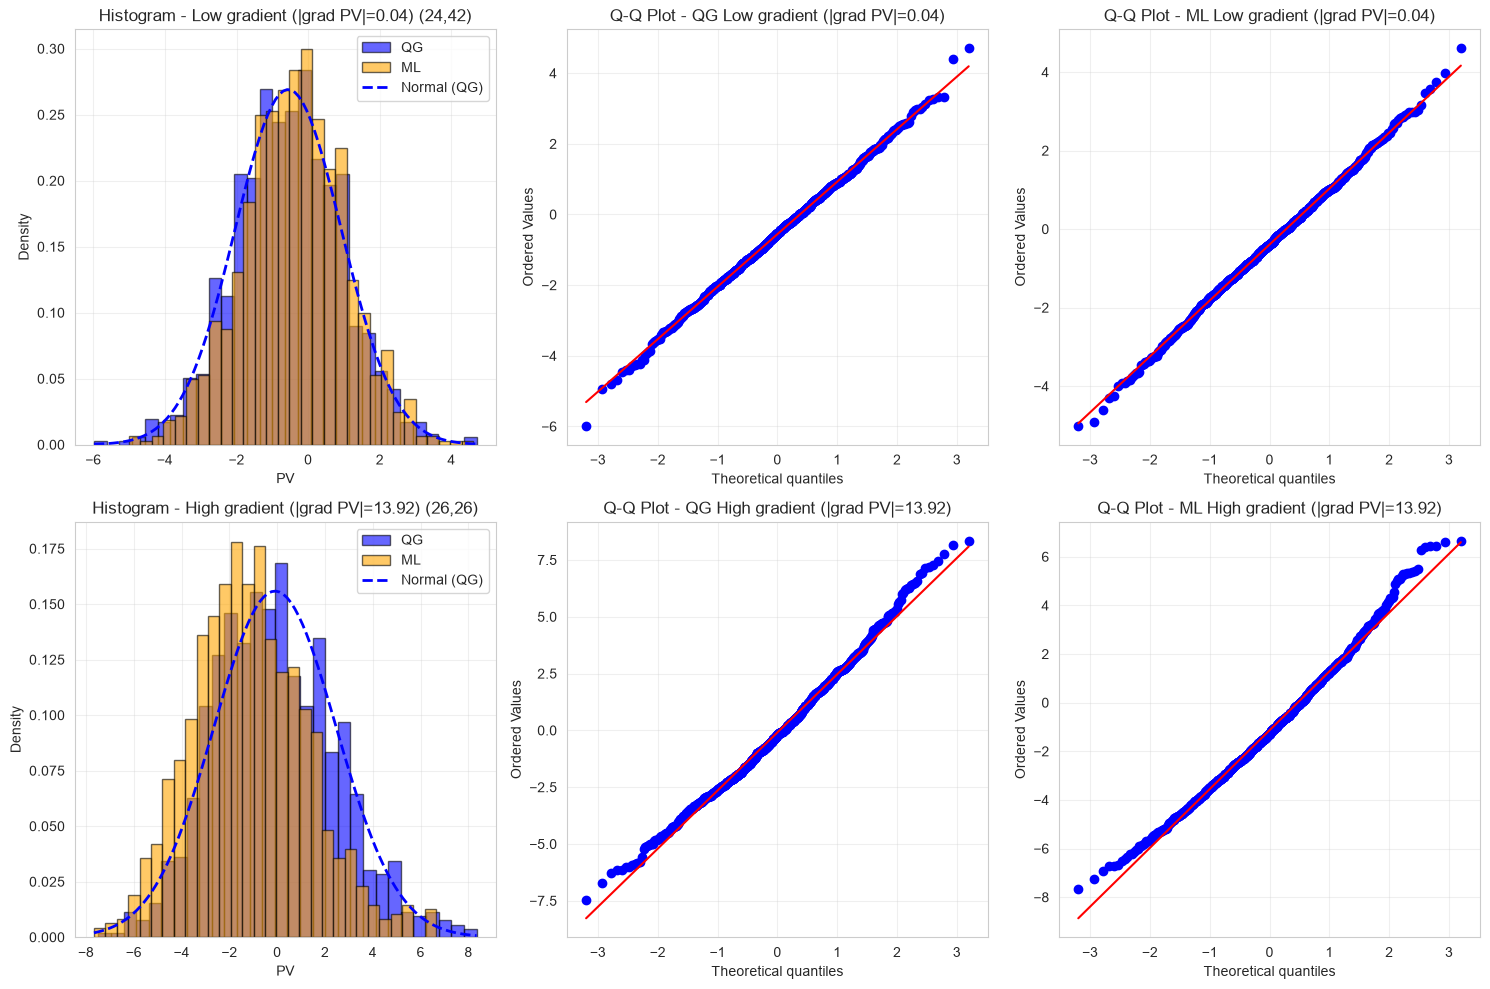

✓ Saved: pv_distributions_detailed.png


In [41]:
# Plot distributions at representative low- and high-gradient points
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Point 1: very small PV gradient
y1, x1 = low_gradient_points[0]
# Point 2: PV gradient greater than 7.5
y2, x2 = high_gradient_points[0]

comparison_points = [
    (y1, x1, f'Low gradient (|grad PV|={pv_qg_gradient_l0[y1, x1]:.2f})'),
    (y2, x2, f'High gradient (|grad PV|={pv_qg_gradient_l0[y2, x2]:.2f})'),
]

for idx, (y, x, title_suffix) in enumerate(comparison_points):
    # QG Model - Histogram
    ax = axes[idx, 0]
    qg_vals = pv_qg[:, 0, y, x]
    ml_vals = pv_ml[:, 0, y, x]
    
    ax.hist(qg_vals, bins=30, density=True, alpha=0.6, label='QG', color='blue', edgecolor='black')
    ax.hist(ml_vals, bins=30, density=True, alpha=0.6, label='ML', color='orange', edgecolor='black')
    
    # Add theoretical normal distribution
    x_range = np.linspace(min(qg_vals.min(), ml_vals.min()), 
                          max(qg_vals.max(), ml_vals.max()), 100)
    mean_qg, std_qg = np.mean(qg_vals), np.std(qg_vals)
    ax.plot(x_range, stats.norm.pdf(x_range, mean_qg, std_qg), 
            'b--', linewidth=2, label='Normal (QG)')
    
    ax.set_xlabel('PV')
    ax.set_ylabel('Density')
    ax.set_title(f'Histogram - {title_suffix} ({y},{x})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Q-Q plots
    for model_idx, (vals, label, color) in enumerate([(qg_vals, 'QG', 'blue'), 
                                                        (ml_vals, 'ML', 'orange')]):
        ax = axes[idx, 1 + model_idx]
        stats.probplot(vals, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot - {label} {title_suffix}')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pv_distributions_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: pv_distributions_detailed.png")

## 7. Analysis Using Nearby Points (Window-Averaged)

ANALYSIS WITH NEARBY POINTS (3x3 window = 9 points)

Center (32,32) - 3x3 window:
  QG  - Shapiro p-value: 0.003261, Skew: -0.2436, Kurt: 0.5174
  ML  - Shapiro p-value: 0.015389, Skew: -0.2052, Kurt: 0.4715

Edge (16,32) - 3x3 window:
  QG  - Shapiro p-value: 0.005443, Skew: -0.1318, Kurt: 0.5266
  ML  - Shapiro p-value: 0.001053, Skew: -0.1700, Kurt: 0.5820

Edge (32,16) - 3x3 window:
  QG  - Shapiro p-value: 0.000234, Skew: -0.2241, Kurt: 0.4836
  ML  - Shapiro p-value: 0.000011, Skew: -0.2973, Kurt: 0.5084

Corner (48,48) - 3x3 window:
  QG  - Shapiro p-value: 0.000018, Skew: -0.3425, Kurt: 0.0117
  ML  - Shapiro p-value: 0.000017, Skew: -0.3420, Kurt: 0.0018


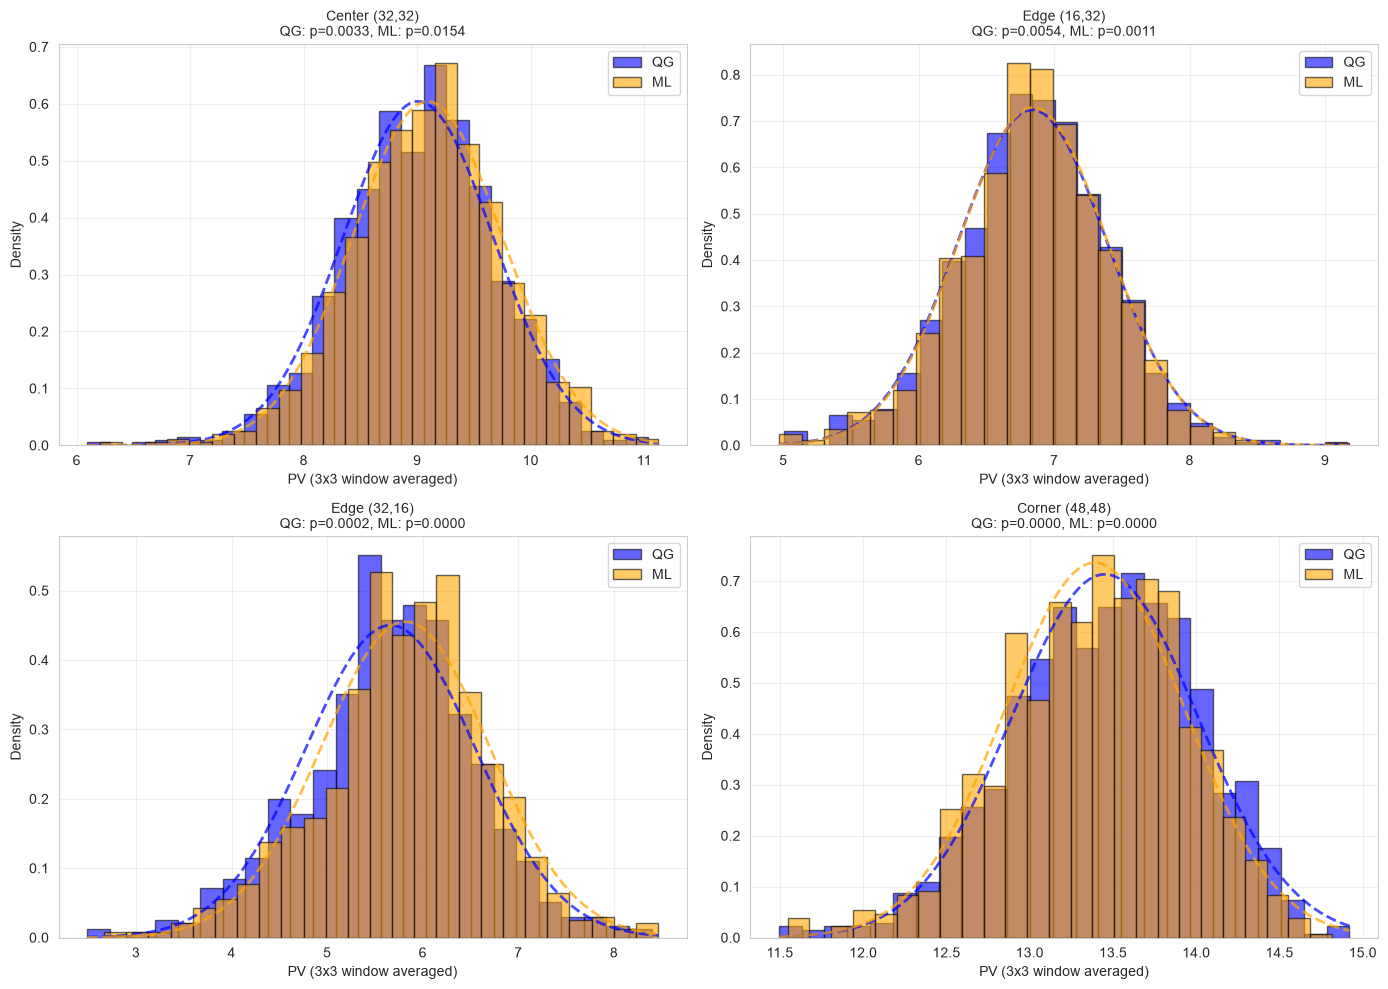


✓ Saved: pv_distributions_windowed.png


In [8]:
# Analyze points with window averaging
print("=" * 80)
print("ANALYSIS WITH NEARBY POINTS (3x3 window = 9 points)")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

window_size = 1  # 3x3 window

# Test points
test_points = [
    (32, 32, 'Center', 0),
    (16, 32, 'Edge', 1),
    (32, 16, 'Edge', 2),
    (48, 48, 'Corner', 3),
]

for y, x, location, plot_idx in test_points:
    res_qg = analyze_normality(pv_qg, layer=0, y=y, x=x, window_size=window_size)
    res_ml = analyze_normality(pv_ml, layer=0, y=y, x=x, window_size=window_size)
    
    ax = axes.flat[plot_idx]
    
    # Comparative histograms
    ax.hist(res_qg['values'], bins=25, density=True, alpha=0.6, label='QG', 
            color='blue', edgecolor='black')
    ax.hist(res_ml['values'], bins=25, density=True, alpha=0.6, label='ML', 
            color='orange', edgecolor='black')
    
    # Theoretical normals
    x_range = np.linspace(min(res_qg['values'].min(), res_ml['values'].min()),
                          max(res_qg['values'].max(), res_ml['values'].max()), 100)
    ax.plot(x_range, stats.norm.pdf(x_range, res_qg['mean'], res_qg['std']), 
            'b--', linewidth=2, alpha=0.7)
    ax.plot(x_range, stats.norm.pdf(x_range, res_ml['mean'], res_ml['std']), 
            'orange', linestyle='--', linewidth=2, alpha=0.7)
    
    title = f'{location} ({y},{x})\n'
    title += f'QG: p={res_qg["shapiro_p"]:.4f}, ML: p={res_ml["shapiro_p"]:.4f}'
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PV (3x3 window averaged)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"\n{location} ({y},{x}) - 3x3 window:")
    print(f"  QG  - Shapiro p-value: {res_qg['shapiro_p']:.6f}, Skew: {res_qg['skew']:.4f}, Kurt: {res_qg['kurtosis']:.4f}")
    print(f"  ML  - Shapiro p-value: {res_ml['shapiro_p']:.6f}, Skew: {res_ml['skew']:.4f}, Kurt: {res_ml['kurtosis']:.4f}")

plt.tight_layout()
plt.savefig('pv_distributions_windowed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: pv_distributions_windowed.png")

## 8. Spatial Analysis - Normality Map Across Grid

Computing normality map for entire grid...
This may take ~30 seconds...
  Processing row 60/64...
✓ Calculation completed


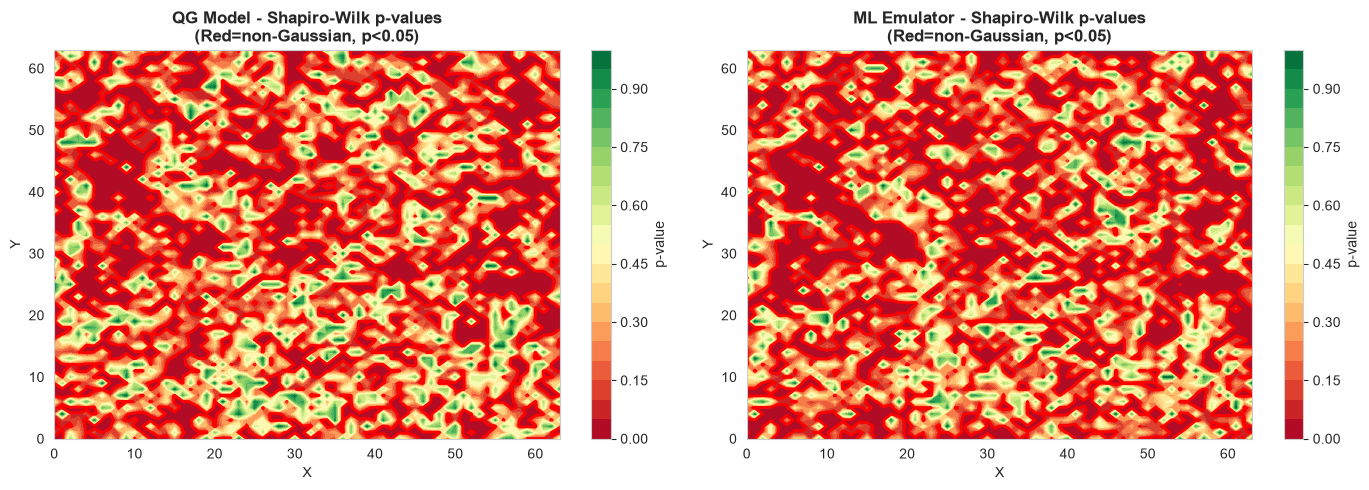

✓ Saved: pv_normality_map.png

Points with non-Gaussian distribution (p < 0.05):
  QG Model: 1959/4096 (47.8%)
  ML Emulator: 2122/4096 (51.8%)


In [9]:
# Calculate p-value map for entire grid (may take a moment)
print("Computing normality map for entire grid...")
print("This may take ~30 seconds...")

ny, nx = pv_qg.shape[2], pv_qg.shape[3]
p_values_qg = np.zeros((ny, nx))
p_values_ml = np.zeros((ny, nx))

# Calculate each point
for j in range(ny):
    if j % 10 == 0:
        print(f"  Processing row {j}/{ny}...", end='\r')
    for i in range(nx):
        _, p_qg = stats.shapiro(pv_qg[:, 0, j, i])
        _, p_ml = stats.shapiro(pv_ml[:, 0, j, i])
        p_values_qg[j, i] = p_qg
        p_values_ml[j, i] = p_ml

print(f"\n✓ Calculation completed")

# Visualize maps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QG Model
im1 = axes[0].contourf(p_values_qg, levels=20, cmap='RdYlGn')
axes[0].contour(p_values_qg, levels=[0.05], colors='red', linewidths=2)
axes[0].set_title('QG Model - Shapiro-Wilk p-values\n(Red=non-Gaussian, p<0.05)', fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('p-value')

# ML Emulator
im2 = axes[1].contourf(p_values_ml, levels=20, cmap='RdYlGn')
axes[1].contour(p_values_ml, levels=[0.05], colors='red', linewidths=2)
axes[1].set_title('ML Emulator - Shapiro-Wilk p-values\n(Red=non-Gaussian, p<0.05)', fontweight='bold')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('p-value')

plt.tight_layout()
plt.savefig('pv_normality_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: pv_normality_map.png")

# Statistics
n_non_gaussian_qg = np.sum(p_values_qg < 0.05)
n_non_gaussian_ml = np.sum(p_values_ml < 0.05)
print(f"\nPoints with non-Gaussian distribution (p < 0.05):")
print(f"  QG Model: {n_non_gaussian_qg}/{ny*nx} ({100*n_non_gaussian_qg/(ny*nx):.1f}%)")
print(f"  ML Emulator: {n_non_gaussian_ml}/{ny*nx} ({100*n_non_gaussian_ml/(ny*nx):.1f}%)")

## 9. Summary and Next Steps

### Key Findings:

1. **Gaussianity**: Compare what percentage of points have Gaussian vs non-Gaussian distributions
2. **Localization**: Where do non-Gaussian points appear? (Near gradients?)
3. **ML vs QG Differences**: Does the ML emulator accurately reproduce non-Gaussian characteristics?
4. **Window Effect**: Does averaging nearby points improve or worsen Gaussianity?

### Next Steps:

1. Identify regions with strong PV gradients and correlate with non-Gaussianity
2. Analyze the second layer (layer 2) if relevant
3. Investigate other variables (relative vorticity, etc.)
4. Compare temporal evolution if necessary